          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
Shape of dataset: (100, 6)
Number of rows: 100
Number of columns: 6

First five rows:
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113

Last five rows:
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918  

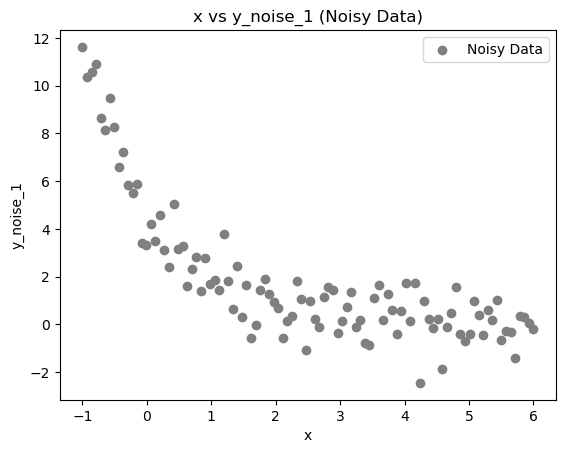

Chi-squared: 77.48597445708178
Degrees of freedom: 98
Reduced chi-squared: 28.538124369084496


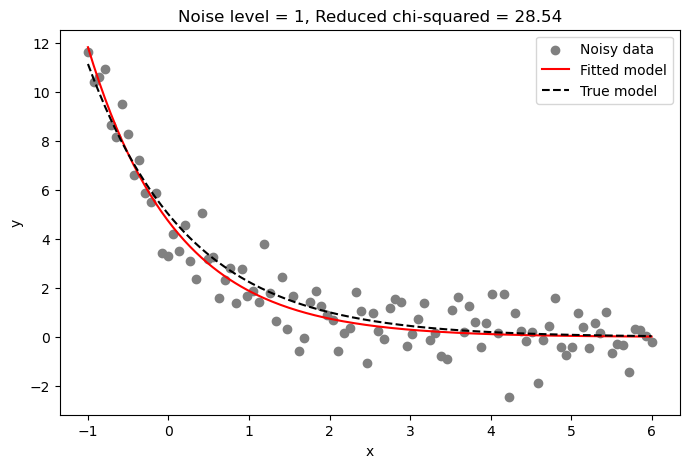

Question 1: As noise level increases, the red fitted line usually drifts farther from the black dotted true line. This is because higher noise = more scatter
Question 2: The reduced chi-squared generally increases as noise increases, because the residuals between the noisy data produces a worse agreement
   Noise level     A_fit     k_fit  Reduced chi-squared
0            1  4.714814  0.918308             0.790673
1            2  5.063889  0.730396             3.649382
2            3  5.609396  0.870372            10.410207
3            4  5.738727  0.725965            12.626832
4            5  4.943458  0.695012            28.538124


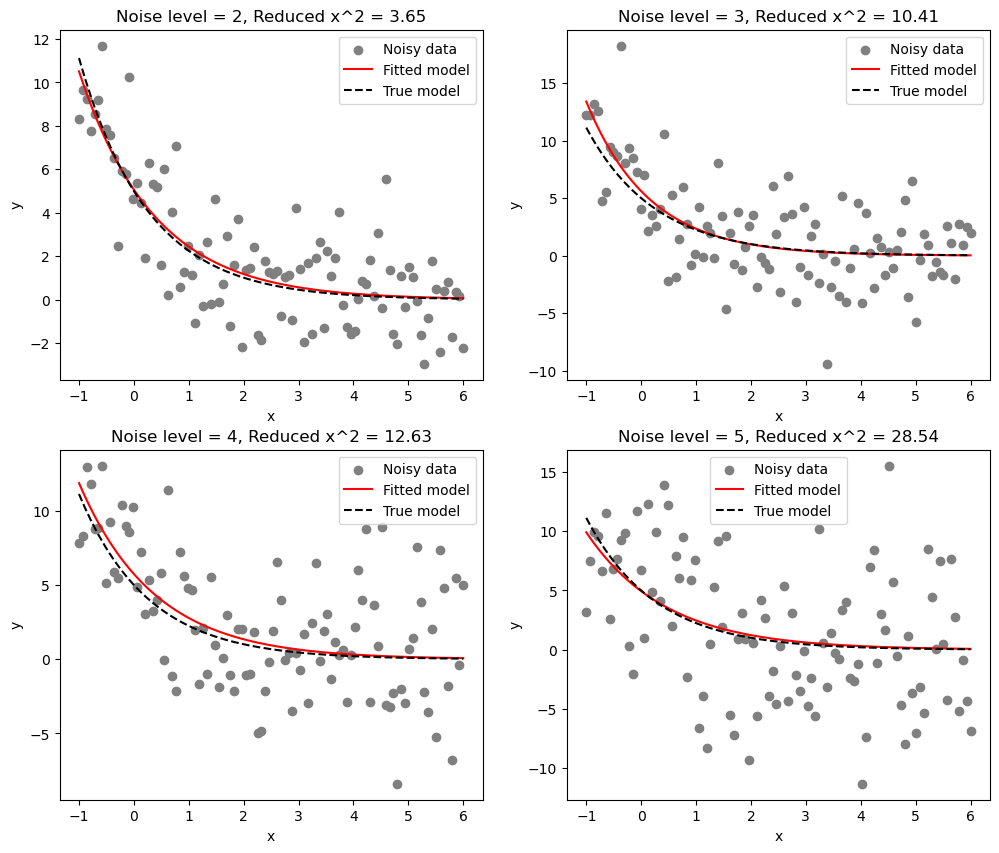

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#2.1 Collect the Data

df = pd.read_csv('noisy_curvefit_data.csv')
print(df.head())

print("Shape of dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nFirst five rows:")
print(df.head())
print("\nLast five rows:")
print(df.tail())
print("\nColumn names:")
print(df.columns)

plt.figure()
plt.scatter(df['x'], df['y_noise_1'], color='gray', label='Noisy Data')

plt.xlabel('x')
plt.ylabel('y_noise_1')
plt.title('x vs y_noise_1 (Noisy Data)')

plt.legend()

plt.show()

#2.2 Fit the Data
x = df['x'].to_numpy()
y = df['y_noise_1'].to_numpy()

def model(x, A, k):
    return A * np.exp(-k * x)

p0 = [1, 1]
popt, pcov = curve_fit(model, x, y, p0=p0)

A_fit = popt[0]
k_fit = popt[1]

residuals = y - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi_reduced = chi2 / dof
print("Chi-squared:", chi2)
print("Degrees of freedom:", dof)
print("Reduced chi-squared:", chi2_reduced)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = model(x_fit, A_fit, k_fit)
y_true = model(x_fit, 5, 0.8)

plt.figure(figsize=(8,5))
plt.scatter(x, y, color='gray', label='Noisy data')
plt.plot(x_fit, y_fit, color='red', label='Fitted model')
plt.plot(x_fit, y_true, color='black', linestyle='--', label='True model')

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Noise level = 1, Reduced chi-squared = {chi2_reduced:.2f}')
plt.legend()
plt.show()

#Compare different noise levels

def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return popt, chi2_reduced

noise_cols = ['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']
noise_levels = [2, 3, 4, 5]

x_fit = np.linspace(x.min(), x.max(), 200)
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for i in range(4):
    y = df[noise_cols[i]].to_numpy()
    popt, chi2_reduced = fit_model(x, y)
    A_fit, k_fit = popt
    y_fit = model(x_fit, A_fit, k_fit)
    y_true = model(x_fit, 5, 0.8)
   
    axs[i].scatter(x, y, color='gray', label=f'Noisy data')
    axs[i].plot(x_fit, y_fit, color='red', label='Fitted model')
    axs[i].plot(x_fit, y_true, color='black', linestyle='--', label='True model')
   
    axs[i].set_xlabel('x')
    axs[i].set_ylabel('y')
    axs[i].set_title(f'Noise level = {noise_levels[i]}, Reduced x^2 = {chi2_reduced:.2f}')
    axs[i].legend()

print('Question 1: As noise level increases, the red fitted line usually drifts farther from the black dotted true line. This is because higher noise = more scatter')
print('Question 2: The reduced chi-squared generally increases as noise increases, because the residuals between the noisy data produces a worse agreement')

#2.4 Save your results
noise_cols = ['y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']
noise_levels = [1, 2, 3, 4, 5]
results = []

for col, noise in zip(noise_cols, noise_levels):
    y = df[col].to_numpy()
    popt, chi2_reduced = fit_model(x, y)
    A_fit, k_fit = popt
    results.append({
        'Noise level': noise,
        'A_fit': A_fit, 
        'k_fit': k_fit,
        'Reduced chi-squared': chi2_reduced
    })

results_df = pd.DataFrame(results)
print(results_df)

results_df.to_csv("noisy_parameters.csv", index=False)

